# Data Preprocessing & Feature Engineering & Train Model


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import OneHotEncoder, MultiLabelBinarizer, OrdinalEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score,root_mean_squared_error,mean_squared_error

## Load data
Drop `Locality` (too high-cardinality / basically an ID) and `Total_Floors` (kept `Floor_No` instead), plus `Property_ID` and `State` (redundant with `City`).

In [4]:
df = pd.read_csv("India_housing_prices.csv").drop(
    columns=["Locality", "Total_Floors", "Property_ID", "State"]
)
df["Amenities"] = df["Amenities"].fillna("None")  # rows with zero amenities
df.head()

,City,Property_Type,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,Furnished_Status,Floor_No,Age_of_Property,Nearby_Schools,Nearby_Hospitals,Public_Transport_Accessibility,Parking_Space,Security,Amenities,Facing,Owner_Type,Availability_Status
0,Delhi,Apartment,4,2538,457.17,0.1801,1993,Semi-furnished,22,32,6,2,High,Yes,Yes,"Clubhouse, Playground, Gym",South,Broker,Under_Construction
1,Lucknow,Apartment,1,654,35.25,0.0539,2009,Unfurnished,5,16,7,8,Low,Yes,Yes,"Playground, Pool, Garden, Clubhouse, Gym",East,Broker,Ready_to_Move
2,Jodhpur,Apartment,1,947,44.88,0.0474,2002,Semi-furnished,15,23,9,2,Low,No,Yes,"Playground, Clubhouse, Gym, Pool",South,Builder,Ready_to_Move
3,Kolkata,Apartment,3,2072,174.43,0.0842,2014,Semi-furnished,21,11,5,0,Medium,Yes,No,"Playground, Gym",North,Builder,Ready_to_Move
4,Kolkata,Independent House,5,2331,197.42,0.0847,2010,Furnished,18,15,6,9,Low,Yes,No,None,West,Owner,Ready_to_Move


## Split into features / target

In [6]:
X = df.drop(columns="Price_in_Lakhs")
y = df["Price_in_Lakhs"]

## Train/test split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)

## One-Hot Encode nominal categorical columns
`City`, `Property_Type`, `Parking_Space`, `Security`, `Facing`

In [10]:
ohe = OneHotEncoder(drop="first", sparse_output=False, dtype="int")
cat_cols = ["City", "Property_Type", "Parking_Space", "Security", "Facing"]

X_train_new = ohe.fit_transform(X_train[cat_cols])
X_train[ohe.get_feature_names_out()] = X_train_new
X_train = X_train.drop(columns=cat_cols)

X_test_new = ohe.transform(X_test[cat_cols])
X_test[ohe.get_feature_names_out()] = X_test_new
X_test = X_test.drop(columns=cat_cols)

X_train.head()

,BHK,Size_in_SqFt,Price_per_SqFt,Year_Built,Furnished_Status,Floor_No,Age_of_Property,Nearby_Schools,Nearby_Hospitals,Public_Transport_Accessibility,...,City_Ludhiana,City_Mumbai,City_Pune,Property_Type_Independent House,Property_Type_Villa,Parking_Space_Yes,Security_Yes,Facing_North,Facing_South,Facing_West
0,4,1904,0.1451,1986,Unfurnished,3,39,6,7,Low,...,0,0,0,0,0,1,0,0,0,0
1,1,529,0.0712,2016,Semi-furnished,28,9,10,5,Low,...,0,0,0,0,0,1,1,0,0,1
2,2,1540,0.0710,1980,Semi-furnished,23,45,0,6,Low,...,0,0,0,1,0,1,1,0,1,0
3,2,1152,0.0681,2019,Furnished,15,6,0,0,Medium,...,0,0,0,0,0,1,1,0,1,0
4,5,2620,0.0577,1993,Semi-furnished,22,32,1,9,Low,...,0,0,0,0,0,1,1,0,1,0


## MultiLabelBinarizer on `Amenities`
Amenities is a comma-separated multi-label column, so it needs `MultiLabelBinarizer` rather than a normal one-hot encoder.

In [12]:
mlb = MultiLabelBinarizer()

X_train["Amenities"] = X_train["Amenities"].str.split(",").apply(lambda x: [i.strip() for i in x])

new_X_train = pd.DataFrame(mlb.fit_transform(X_train["Amenities"]), columns=mlb.classes_)
new_X_test = pd.DataFrame(mlb.transform(X_test["Amenities"]), columns=mlb.classes_)

X_train[mlb.classes_] = new_X_train
X_test[mlb.classes_] = new_X_test

X_train = X_train.drop(columns="Amenities")
X_test = X_test.drop(columns="Amenities")

X_train.head()

,BHK,Size_in_SqFt,Price_per_SqFt,Year_Built,Furnished_Status,Floor_No,Age_of_Property,Nearby_Schools,Nearby_Hospitals,Public_Transport_Accessibility,...,Security_Yes,Facing_North,Facing_South,Facing_West,Clubhouse,Garden,Gym,None,Playground,Pool
0,4,1904,0.1451,1986,Unfurnished,3,39,6,7,Low,...,0,0,0,0,1,1,1,0,1,1
1,1,529,0.0712,2016,Semi-furnished,28,9,10,5,Low,...,1,0,0,1,1,1,0,0,0,0
2,2,1540,0.0710,1980,Semi-furnished,23,45,0,6,Low,...,1,0,1,0,0,1,1,0,1,0
3,2,1152,0.0681,2019,Furnished,15,6,0,0,Medium,...,1,0,1,0,1,0,0,0,1,0
4,5,2620,0.0577,1993,Semi-furnished,22,32,1,9,Low,...,1,0,1,0,1,1,1,0,0,0


## Ordinal Encode ranked categorical columns
`Furnished_Status` (Unfurnished < Semi-furnished < Furnished) and `Public_Transport_Accessibility` (Low < Medium < High) have a natural order, so use `OrdinalEncoder`.

In [14]:
oe = OrdinalEncoder(
    categories=[
        ["Unfurnished", "Semi-furnished", "Furnished"],
        ["Low", "Medium", "High"],
    ],
    dtype="int",
)

X_train[["Furnished_Status", "Public_Transport_Accessibility"]] = oe.fit_transform(
    X_train[["Furnished_Status", "Public_Transport_Accessibility"]]
)
X_test[["Furnished_Status", "Public_Transport_Accessibility"]] = oe.transform(
    X_test[["Furnished_Status", "Public_Transport_Accessibility"]]
)

X_train.head()

,BHK,Size_in_SqFt,Price_per_SqFt,Year_Built,Furnished_Status,Floor_No,Age_of_Property,Nearby_Schools,Nearby_Hospitals,Public_Transport_Accessibility,...,Security_Yes,Facing_North,Facing_South,Facing_West,Clubhouse,Garden,Gym,None,Playground,Pool
0,4,1904,0.1451,1986,0,3,39,6,7,0,...,0,0,0,0,1,1,1,0,1,1
1,1,529,0.0712,2016,1,28,9,10,5,0,...,1,0,0,1,1,1,0,0,0,0
2,2,1540,0.0710,1980,1,23,45,0,6,0,...,1,0,1,0,0,1,1,0,1,0
3,2,1152,0.0681,2019,2,15,6,0,0,1,...,1,0,1,0,1,0,0,0,1,0
4,5,2620,0.0577,1993,1,22,32,1,9,0,...,1,0,1,0,1,1,1,0,0,0


## Drop leaky / low-signal columns
`Price_per_SqFt` is mathematically derived from `Price_in_Lakhs` (target leakage), and `Owner_Type`, `Availability_Status`, `Year_Built` don't add real information here (`Age_of_Property` already encodes the year).

In [16]:
X_train = X_train.drop(columns=["Price_per_SqFt", "Owner_Type", "Availability_Status", "Year_Built"])
X_test = X_test.drop(columns=["Price_per_SqFt", "Owner_Type", "Availability_Status", "Year_Built"])

## Scale numeric columns (MinMax)

In [18]:
scaler_X = MinMaxScaler()
num_cols = ["Size_in_SqFt", "Age_of_Property"]

X_train[num_cols] = scaler_X.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler_X.transform(X_test[num_cols])

X_train.head()

,BHK,Size_in_SqFt,Furnished_Status,Floor_No,Age_of_Property,Nearby_Schools,Nearby_Hospitals,Public_Transport_Accessibility,City_Bengaluru,City_Chandigarh,...,Security_Yes,Facing_North,Facing_South,Facing_West,Clubhouse,Garden,Gym,None,Playground,Pool
0,4,0.364545,0,3,0.863636,6,7,0,0,0,...,0,0,0,0,1,1,1,0,1,1
1,1,0.052045,1,28,0.181818,10,5,0,0,0,...,1,0,0,1,1,1,0,0,0,0
2,2,0.281818,1,23,1.000000,0,6,0,0,0,...,1,0,1,0,0,1,1,0,1,0
3,2,0.193636,2,15,0.113636,0,0,1,0,0,...,1,0,1,0,1,0,0,0,1,0
4,5,0.527273,1,22,0.704545,1,9,0,0,0,...,1,0,1,0,1,1,1,0,0,0


In [19]:
scaler_y = MinMaxScaler()

y_train = pd.Series(scaler_y.fit_transform(y_train.to_frame(name="target")).ravel())
y_test = pd.Series(scaler_y.transform(y_test.to_frame(name="target")).ravel())

y_train.head()

0    0.177419
1    0.016607
2    0.064925
3    0.044105
4    0.093070
dtype: float64

## Save the processed splits

### Feature importance check
A quick sanity check that the tree is picking up genuine signal (size/BHK should dominate) rather than fitting to noise.

In [22]:
tree = DecisionTreeRegressor(max_depth=10, random_state=42)
tree.fit(X_train, y_train)


DecisionTreeRegressor(max_depth=10, random_state=42)

In [23]:
importances = pd.Series(tree.feature_importances_, index=X_train.columns).sort_values(ascending=False)
importances

Size_in_SqFt                       0.418435
City_Mumbai                        0.289779
City_Delhi                         0.128527
City_Bengaluru                     0.061884
Property_Type_Villa                0.023510
City_Pune                          0.019133
City_Hyderabad                     0.016546
City_Chennai                       0.013951
City_Chandigarh                    0.011699
Age_of_Property                    0.006079
City_Kolkata                       0.004457
Furnished_Status                   0.002855
Property_Type_Independent House    0.001188
Public_Transport_Accessibility     0.001178
Floor_No                           0.000290
Nearby_Schools                     0.000141
Nearby_Hospitals                   0.000118
Facing_North                       0.000045
Facing_West                        0.000026
Facing_South                       0.000022
Security_Yes                       0.000020
None                               0.000020
Parking_Space_Yes               

# Model Train

In [25]:
model=LinearRegression()

In [26]:
model.fit(X_train,y_train)

LinearRegression()

In [27]:
model.feature_names_in_

array(['BHK', 'Size_in_SqFt', 'Furnished_Status', 'Floor_No',
       'Age_of_Property', 'Nearby_Schools', 'Nearby_Hospitals',
       'Public_Transport_Accessibility', 'City_Bengaluru',
       'City_Chandigarh', 'City_Chennai', 'City_Delhi', 'City_Hyderabad',
       'City_Indore', 'City_Jaipur', 'City_Jodhpur', 'City_Kochi',
       'City_Kolkata', 'City_Lucknow', 'City_Ludhiana', 'City_Mumbai',
       'City_Pune', 'Property_Type_Independent House',
       'Property_Type_Villa', 'Parking_Space_Yes', 'Security_Yes',
       'Facing_North', 'Facing_South', 'Facing_West', 'Clubhouse',
       'Garden', 'Gym', 'None', 'Playground', 'Pool'], dtype=object)

In [28]:
model.score(X_test,y_test)

0.8734992346383575

In [29]:
y_pred=model.predict(X_test)

In [30]:
r2_score(y_test,y_pred)

0.8734992346383575

In [31]:
root_mean_squared_error(y_test,y_pred)

0.03474382004675016

Text(0, 0.5, 'y_pred')

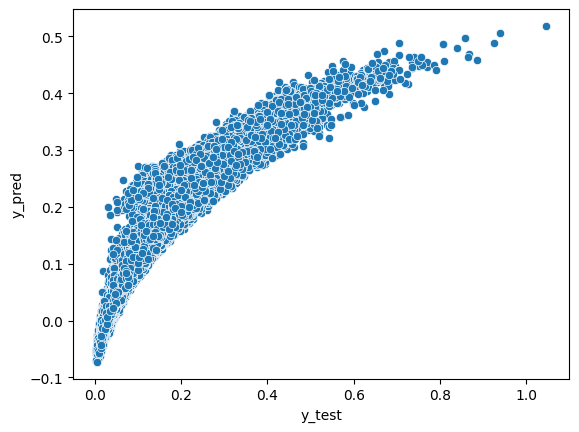

In [32]:
sns.scatterplot(x=y_test,y=y_pred)
plt.xlabel("y_test")
plt.ylabel("y_pred")

In [33]:
feature_columns=['BHK', 'Size_in_SqFt', 'Furnished_Status', 'Floor_No',
       'Age_of_Property', 'Nearby_Schools', 'Nearby_Hospitals',
       'Public_Transport_Accessibility', 'City_Bengaluru',
       'City_Chandigarh', 'City_Chennai', 'City_Delhi', 'City_Hyderabad',
       'City_Indore', 'City_Jaipur', 'City_Jodhpur', 'City_Kochi',
       'City_Kolkata', 'City_Lucknow', 'City_Ludhiana', 'City_Mumbai',
       'City_Pune', 'Property_Type_Independent House',
       'Property_Type_Villa', 'Parking_Space_Yes', 'Security_Yes',
       'Facing_North', 'Facing_South', 'Facing_West', 'Clubhouse',
       'Garden', 'Gym', 'None', 'Playground', 'Pool']

In [34]:
bundle = {
    "model": lr,
    "ohe": ohe,
    "mlb": mlb,
    "oe": oe,
    "scaler_X": scaler_X,
    "scaler_y": scaler_y,
    "cat_cols": cat_cols,
    "num_cols": num_cols,
    "feature_columns": list(X_train.columns),
    "amenity_classes": list(mlb.classes_),
    "city_options": sorted(df["City"].unique().tolist()),
    "property_type_options": sorted(df["Property_Type"].unique().tolist()),
    "facing_options": sorted(df["Facing"].unique().tolist()),
}


NameError: name 'lr' is not defined

In [ ]:
import pickle

with open('House_price_model.pkl', 'wb') as file:
    pickle.dump(bundle, file)

print("Bundle saved successfully.")


In [ ]:
mlb.classes_